In [15]:
import os
import re
import sys
import json
import torch
import shlex
import random
import logging
import numpy as np
import torch.utils.data as D
from copy import deepcopy
from pathlib import Path
from datetime import datetime
from socket import gethostname
from argparse import Namespace
from setproctitle import setproctitle
from src.dataset import ETHDataset, UCYDataset, SDDDataset, GCDataset, WayMoDataset, ORCADataset
from src.model import Model, RelativeModel, NewModel
from src.diffusion import DDPM, DDIM
from src.utils.logger import init_logger
from src.utils.seed import seed_all
from src.utils.timer import NamedTimer
from src.utils.auto_gpu import AutoGPU
from src.utils.fix_parser import add_negation_flags, add_minus_flags
from src.utils.tag2ansi import tag2ansi
from src.utils.use_npu import USE_NPU, npu_attention_fallback_context
from src.tasks import test_once

args = Namespace(**json.load(open('./logs/train/zara02_unified_K=10-from-seperate/args.json', 'r')))
dataset = UCYDataset.load_data(args, './data/UCY/data/data_zara/crowds_zara02.vsp')
loader = D.DataLoader(
    dataset,
    shuffle=False,
    batch_size=args.batch_size // args.sample_num,  # 在实际测试时 batch_size 会乘上 sample_num，可能会很大导致 OOM
    num_workers=args.num_workers,
    collate_fn=dataset.collate_fn,
)
model = RelativeModel(args).to(args.device)
_logger = logging.getLogger("src.test")
init_logger(
    "src",
    exp_name=args.exp_name,
    info_level="debug" if args.debug else "info",
)

checkpoint_path = Path('logs/train/zara02_unified_K=10/best.pth')
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint {checkpoint_path} not found!")
checkpoint = torch.load(checkpoint_path, map_location=args.device)
start_epoch = checkpoint["epoch"] + 1
if 'args' in checkpoint:
    saved_args = checkpoint['args']
    for key in sorted(set(saved_args.keys()) | set(vars(args).keys())):
        if key in [
            'device', 'save_dir', 'save_path', 'command', 'name', 'exp_name',
            'seed', 'reload_checkpoint', 'test_before_train', 'test_per_epoch',
            'p_drop_destination', 'p_drop_map', 'p_drop_speed',
        ]:
            continue
        val1 = saved_args.get(key, None)
        val2 = getattr(args, key, None)
        if val1 != val2:
            _logger.warning(
                f"Argument '{key}' differs from the saved checkpoint: "
                f"saved_args={val1} vs. current_args={val2}"
            )
model.load_state_dict(checkpoint["model"])
_logger.note(tag2ansi(f"Checkpoint loaded from [underline green]{checkpoint_path}[reset], resume from epoch [underline green]{start_epoch}[reset]."))
criterion = torch.nn.MSELoss()
diffusion = DDIM(args)
start_epoch = 0

[zara02_unified_K=10-from-seperate|ucy_dataset|I|Feb08 16:55:13|0:03:28.935550] Loading cached dataset from data/.cache/zara-crowds_zara02_2.5_8_1_1_1.pkl
[zara02_unified_K=10-from-seperate|test|W|Feb08 16:55:13|0:00:00.105622] (../../../../../../tmp/ipykernel_2660660/2832674943.py:63) Argument 'batch_size' differs from the saved checkpoint: saved_args=128 vs. current_args=256
[zara02_unified_K=10-from-seperate|test|W|Feb08 16:55:13|0:00:00.106467] (../../../../../../tmp/ipykernel_2660660/2832674943.py:63) Argument 'lr' differs from the saved checkpoint: saved_args=0.0002 vs. current_args=0.0001
[zara02_unified_K=10-from-seperate|test|N|Feb08 16:55:13|0:00:00.111204] Checkpoint loaded from logs/train/zara02_unified_K=10/best.pth, resume from epoch 2851.


In [ ]:
torch.set_grad_enabled(False)
model.eval()
test_records = test_once(args, [loader], model, criterion, diffusion, start_epoch)

  0%|          | 0/42 [00:00<?, ?it/s]/mnt/mergerfs/yuzihan/MergedWorkSpace/35-HuaweiCrowdSimulation/HuaweiCrowdSimulationCode/src/tasks/test_once.py:228: RuntimeWarning: All-NaN slice encountered
  max_err = np.nanmax((pos_true - future_pos).abs().cpu().numpy(), axis=(-2, -1))
/mnt/mergerfs/yuzihan/MergedWorkSpace/35-HuaweiCrowdSimulation/HuaweiCrowdSimulationCode/src/tasks/test_once.py:293: RuntimeWarning: Mean of empty slice
  f"[#66CCFF]X_ERROR (normal)={np.nanmean(records['norm_err']):.4f}, "
/mnt/mergerfs/yuzihan/MergedWorkSpace/35-HuaweiCrowdSimulation/HuaweiCrowdSimulationCode/src/tasks/test_once.py:294: RuntimeWarning: Mean of empty slice
  f"[#66CCFF]Y_ERROR (tangential)={np.nanmean(records['tan_err']):.4f}, "
[zara02_unified_K=10-from-seperate|test_once|I|Feb08 16:52:09|0:00:24.822908] [Epoch 0/10000] Eval on zara-crowds_zara02: Accuracy=93.34%, Loss=0.0541, ADE=0.1588, FDE=0.3315, X_ERROR (normal)=nan, Y_ERROR (tangential)=nan, Collision-Ped=-5.52% (+67.57%), Collision-Veh=

In [19]:
import time
import torch
import logging
import numpy as np
import torch.nn as nn
import torch.utils.data as D
from tqdm import tqdm
from typing import List, Dict
from src.model import Model
from src.diffusion import DDPM
from src.utils.timer import NamedTimer
from src.utils.tag2ansi import tag2ansi
from src.tasks.guidance import guidance
from src.tasks.simulate import SimulateState
from src.tasks.test_once import get_collision_rate

test_timer = NamedTimer(unit='it', mode='pace')
records_list = []
map_data = loader.dataset.map_data
map = torch.from_numpy(map_data.map).to(args.device).float()
test_timer.add('prepare data')
model.set_map_embedding(
    map=map,
    xmin=map_data.xmin,
    xmax=map_data.xmax,
    ymin=map_data.ymin,
    ymax=map_data.ymax,
)
test_timer.add('embed map')
records = dict(
    pos_pred=[], pos_true=[],
    collision_ped=[], collision_ped_base=[]
)
for batch_idx, batch in enumerate(tqdm(loader, disable=False, leave=False, dynamic_ncols=True)):
    pos = batch['pos'].to(args.device)  # (batch_size, #pedestrian, 2)
    vel = batch['vel'].to(args.device)  # (batch_size, #pedestrian, 2)
    hst = batch['hst'].to(args.device)  # (batch_size, #pedestrian, hist_step, 2)
    des = batch['des'].to(args.device)  # (batch_size, #pedestrian, 2)
    spd = batch['spd'].to(args.device)  # (batch_size, #pedestrian, 1)
    veh = batch['veh'].to(args.device)  # (batch_size, #vehicle, hist_step + 1, 2)
    future_acc = batch['future_acc'].to(args.device)  # (batch_size, #pedestrian, pred_step*roll_step, 2)
    future_pos = batch['future_pos'].to(args.device)  # (batch_size, #pedestrian, pred_step*roll_step, 2)
    future_veh = batch['future_veh'].to(args.device)  # (batch_size, #vehicle, pred_step*roll_step, 2)
    ped_length = batch['ped_length'].to(args.device)  # (batch_size,)
    veh_length = batch['veh_length'].to(args.device)  # (batch_size,)

    S = args.sample_num  # 采样次数
    N = args.denoise_step  # 采样步数
    assert args.T % N == 0, f"试图使用 {N} 步采样，然而训练步数 {args.T} mod {N} 不等于 0!"
    assert 1 <= args.step_offset <= args.T // N, f"step_offset 应该取值于 {{1, ..., {args.T // N}}}!"
    pos_now = pos.repeat(S, 1, 1)  # (S*B, #pedestrian, 2)
    vel_now = vel.repeat(S, 1, 1)  # (S*B, #pedestrian, 2)
    hst_now = hst.repeat(S, 1, 1, 1)  # (S*B, #pedestrian, hist_step, 2)
    des_now = des.repeat(S, 1, 1)  # (S*B, #pedestrian, 2)
    spd_now = spd.repeat(S, 1, 1)  # (S*B, #pedestrian, 1)
    veh_now = veh.repeat(S, 1, 1, 1)  # (S*B, #vehicle, hist_step + 1, 2)
    ped_length_repeat = ped_length.repeat(S)  # (S*B,)
    veh_length_repeat = veh_length.repeat(S)  # (S*B,)
    test_timer.add('prepare data', n=0)

    for_plot = []
    acc_pred = []
    start_time = time.time()
    for step in range(args.roll_step):
        model.set_veh_embedding(veh=veh_now)
        model.set_ped_embedding(pos=pos_now, vel=vel_now, hst=hst_now, des=des_now, spd=spd_now)
        model.set_sur_info()
        test_timer.add('embed data')

        shape = list(future_acc.shape)
        shape[0] *= S
        shape[2] = args.pred_step
        xt = torch.randn(shape, device=args.device)  # 从噪声开始
        for_plot.append([diffusion.noise_to_x0(xt=xt, denoise_t=args.T, noise=0) / args.scale_accelerate])
        stride = args.T // N
        steps = reversed(range(args.step_offset, args.T+1, stride))
        for t in tqdm(steps, disable=True, leave=False, dynamic_ncols=True):
            noisy_acc = xt
            denoise_t = torch.full((xt.shape[0],), t, device=args.device, dtype=torch.long)
            output = model(
                noisy_acc=noisy_acc, 
                denoise_t=denoise_t,
                ped_length=ped_length_repeat, 
                veh_length=veh_length_repeat,
            )  # (S*B, #pedestrian, pred_step, 2)
            ## 获取估计的 x0
            x0 = diffusion.noise_to_x0(xt, denoise_t, output) if args.predict_noise else output
            ## 尝试各种引导，各种 guidance 应为 0~1 左右的系数
            state = SimulateState(
                df_ped=None, df_veh=None, map_data=None, 
                ped_list=None, veh_list=None, frame=None,
                pos_now=pos_now, vel_now=vel_now, des_now=des_now, 
                hst_now=hst_now, spd_now=spd_now, veh_now=veh_now,
            )
            x0 = x0 + guidance(args, x0, state, model, diffusion, noisy_acc, xt, denoise_t, ped_length_repeat, veh_length_repeat)
            ## 去噪
            xt = diffusion.denoise(xt, t, x0=x0, stride=min(stride, t))
            for_plot[-1].append(x0 / args.scale_accelerate)

        acc_new = xt / args.scale_accelerate  # (S*B, #pedestrian, pred_step, 2)
        acc_pred.append(acc_new)
        test_timer.add('denoise')

        vel_new = vel_now.unsqueeze(-2) + acc_new.cumsum(dim=-2) / args.fps  # (S*B, #pedestrian, pred_step, 2)
        pos_new = pos_now.unsqueeze(-2) + vel_new.cumsum(dim=-2) / args.fps  # (S*B, #pedestrian, pred_step, 2)
        veh_new = future_veh[:, :, step*args.pred_step:(step+1)*args.pred_step, :].repeat(S, 1, 1, 1)  # (S*B, #vehicle, pred_step, 2)

        hst_now = torch.cat([hst_now, pos_now.unsqueeze(-2), pos_new], dim=-2)[:, :, -args.hist_step-1:-1, :] # (S*B, #pedestrian, hist_step, 2)
        veh_now = torch.cat([veh_now, veh_new], dim=-2)[:, :, -args.hist_step-1:, :]  # (S*B, #vehicle, hist_step + 1, 2)
        pos_now = pos_new[:, :, -1, :] # (S*B, #pedestrian, 2)
        vel_now = vel_new[:, :, -1, :] # (S*B, #pedestrian, 2)
        test_timer.add('rollout')
    rollout_time = (time.time() - start_time) / args.roll_step

    acc_pred = torch.concat(acc_pred, dim=-2)  # (S*B, #pedestrian, roll_step*pred_step, 2)
    batch_size, ped_num, _, _ = future_acc.shape
    acc_pred = acc_pred.view(S, batch_size, ped_num, args.roll_step*args.pred_step, 2)  # (S, B, #pedestrian, roll_step*pred_step, 2)
    # 获取有效的行人掩模
    mask = torch.arange(ped_num, device=args.device).expand(batch_size, ped_num) < ped_length.unsqueeze(-1)  # (B, #pedestrian)
    # 计算 pos_true 和 vel_true
    acc_true = future_acc # (B, #pedestrian, roll_step*pred_step, 2)
    vel_true = vel.unsqueeze(-2) + acc_true.cumsum(dim=-2) / args.fps # (B, #pedestrian, roll_step*pred_step, 2)
    pos_true = pos.unsqueeze(-2) + vel_true.cumsum(dim=-2) / args.fps # (B, #pedestrian, roll_step*pred_step, 2)
    max_err = np.nanmax((pos_true - future_pos).abs().cpu().numpy(), axis=(-2, -1))
    _logger.debug(
        f"pos_true 和 future 最大差距 > 1: {(max_err > 1).mean():.2%}, "
        f"pos_true 和 future 最大差距 > 1e-6: {(max_err > 1e-6).mean():.2%}"
    )
    # pos_true = future_pos # (B, #pedestrian, roll_step*pred_step, 2)
    # 计算 loss
    # 计算 distance error
    vel_pred = vel.unsqueeze(-2) + acc_pred.cumsum(dim=-2) / args.fps  # (S, B, #pedestrian, roll_step*pred_step, 2)
    pos_pred = pos.unsqueeze(-2) + vel_pred.cumsum(dim=-2) / args.fps  # (S, B, #pedestrian, roll_step*pred_step, 2)
    dis_err = (pos_pred - pos_true).norm(dim=-1) # (S, B, #pedestrian, roll_step*pred_step)
    test_timer.add('evaluate')
    # 移除 padding 的行人
    dis_err = dis_err[:, mask, :] # (S, valid{B*#pedestrian}, roll_step*pred_step)
    # 选择 ade 最佳的 sample
    sample_idx = dis_err.mean(dim=-1).argmin(dim=0)  # (valid{B*#pedestrian},)
    valid_idx = torch.arange(dis_err.shape[1], device=args.device)  # (valid{B*#pedestrian},)
    dis_err = dis_err[sample_idx, valid_idx, :]  # (valid{B*#pedestrian}, roll_step*pred_step)
    # 计算 ade, fde
    # 计算切向误差和法向误差
    # 计算碰撞数
    collision_ped, collision_veh, collision_map = get_collision_rate(args, map_data, future_veh, veh_length, mask, pos_pred)
    records['collision_ped'].append(collision_ped)
    collision_ped_base, collision_veh_base, collision_map_base = get_collision_rate(args, map_data, future_veh, veh_length, mask, pos_true.unsqueeze(0))
    records['collision_ped_base'].append(collision_ped_base)

    break

  0%|          | 0/42 [00:00<?, ?it/s]

/tmp/ipykernel_2660660/3344094320.py:124: RuntimeWarning: All-NaN slice encountered
  max_err = np.nanmax((pos_true - future_pos).abs().cpu().numpy(), axis=(-2, -1))
                                      

In [20]:
collision_ped

0.32428571581840515

In [21]:
collision_ped_base

0.5444444417953491

In [23]:
pos_true.shape, pos_pred.shape

(torch.Size([25, 6, 12, 2]), torch.Size([10, 25, 6, 12, 2]))

(np.float64(-3.278591203689575),
 np.float64(10.454520273208619),
 np.float64(2.392798912525177),
 np.float64(8.213894593715668))

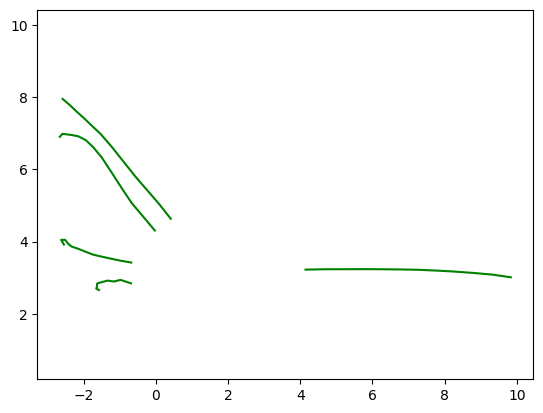

In [61]:
import matplotlib.pyplot as plt
for i in pos_pred[5, -1, mask[-1, :], :, :]:
    plt.plot(i[:, 0].cpu(), i[:, 1].cpu(), 'g-')
plt.axis('equal')

In [ ]:
S, B, P, T, _ = pos_true.unsqueeze(0).shape
flat_pos = pos_true.unsqueeze(0).permute(0, 1, 3, 2, 4).reshape(-1, P, 2)  ## 将 (S, B, P, T, 2) -> (S, B, T, P, 2) -> (S*B*T, P, 2)
dist_matrix = torch.cdist(flat_pos, flat_pos, p=2)  # (S*B*T, P, P)
eye_matrix = torch.eye(P, device=pos_true.unsqueeze(0).device, dtype=torch.bool).unsqueeze(0)
        # 只有当行人 i 和行人 j 都有效 (mask=True) 时才计入碰撞
mask_expanded = mask.unsqueeze(0).unsqueeze(2).expand(S, -1, T, -1).reshape(-1, P) # (B, P) -> (1, B, 1, P) -> (S, B, T, P) -> (S*B*T, P)
valid_pair_mask = mask_expanded.unsqueeze(2) & mask_expanded.unsqueeze(1)
        # fiends = (dist_matrix.reshape(S, B, T, P, P) < args.collision_threshold).float().mean(axis=2)
collision_matrix = (
            (dist_matrix < args.collision_threshold) &
            (~eye_matrix) &
            valid_pair_mask
        )
collision_rate = collision_matrix.sum() / (S * mask.sum() * T)
collision_ped = collision_rate.item()


In [33]:
collision_matrix.shape

torch.Size([300, 6, 6])

In [46]:
collision_matrix.flatten(-2, -1).float().mean(dim=-1)

tensor([0.0000, 0.0000, 0.0556, 0.0556, 0.0556, 0.0556, 0.0556, 0.0556, 0.0556,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0556, 0.0556, 0.0556, 0.0556, 0.0556,
        0.0556, 0.0556, 0.0000, 0.0000, 0.0000, 0.0000, 0.0556, 0.0556, 0.0556,
        0.0556, 0.0556, 0.0556, 0.0556, 0.0000, 0.0000, 0.0000, 0.0000, 0.0556,
        0.0556, 0.0556, 0.0556, 0.0556, 0.0556, 0.0556, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0556, 0.0556, 0.0556, 0.0556, 0.0556, 0.0556, 0.0556, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0556, 0.0556, 0.0556, 0.0556, 0.0556, 0.0556,
        0.0556, 0.0000, 0.0000, 0.0000, 0.0000, 0.0556, 0.0556, 0.0556, 0.0556,
        0.0556, 0.0556, 0.0556, 0.0000, 0.0000, 0.0000, 0.0000, 0.0556, 0.0556,
        0.0556, 0.0556, 0.0556, 0.0556, 0.0556, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0556, 0.0556, 0.0556, 0.0556, 0.0556, 0.0000, 0.0556, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0556, 0.0556, 0.0556, 0.0556, 0.0556, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [49]:
mask[-1]

tensor([ True,  True,  True,  True,  True, False], device='cuda:4')

In [51]:
mask.float().mean()

tensor(0.7000, device='cuda:4')

In [35]:
S, mask.sum(), T, mask.shape

(1, tensor(105, device='cuda:4'), 12, torch.Size([25, 6]))

In [54]:
collision_matrix[-1]

tensor([[False,  True, False, False, False, False],
        [ True, False, False, False, False, False],
        [False, False, False, False, False, False],
        [False, False, False, False,  True, False],
        [False, False, False,  True, False, False],
        [False, False, False, False, False, False]], device='cuda:4')

In [53]:
mask[-1]

tensor([ True,  True,  True,  True,  True, False], device='cuda:4')